In [ ]:
import sys
import os
import glob
import pickle
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import torch

import numpy as np
import pandas as pd

sys.path.append(os.path.abspath(".")) 
sys.path.append(os.path.abspath("pipeline/02_train_sae"))

from train_sae import SAE

## Check the global explanations

In [ ]:
base_ckpt_dir = "model/sae_collapsed"
concepts_dir = Path("data/concept_names")

model_names = ["frob", "noort", "ortsae", "srip"]

cifar10_classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

weights_by_model = {}

for name in model_names:
    ckpt_path = glob.glob(base_ckpt_dir + f"/cbm_collapsed_{name}_l11e-4*")[0]
    ckpt = torch.load(ckpt_path, map_location="cpu")
    W = ckpt["state_dict"]["linear.weight"]
    weights_by_model[name] = W

num_features = weights_by_model[model_names[0]].shape[1]
topk = 5

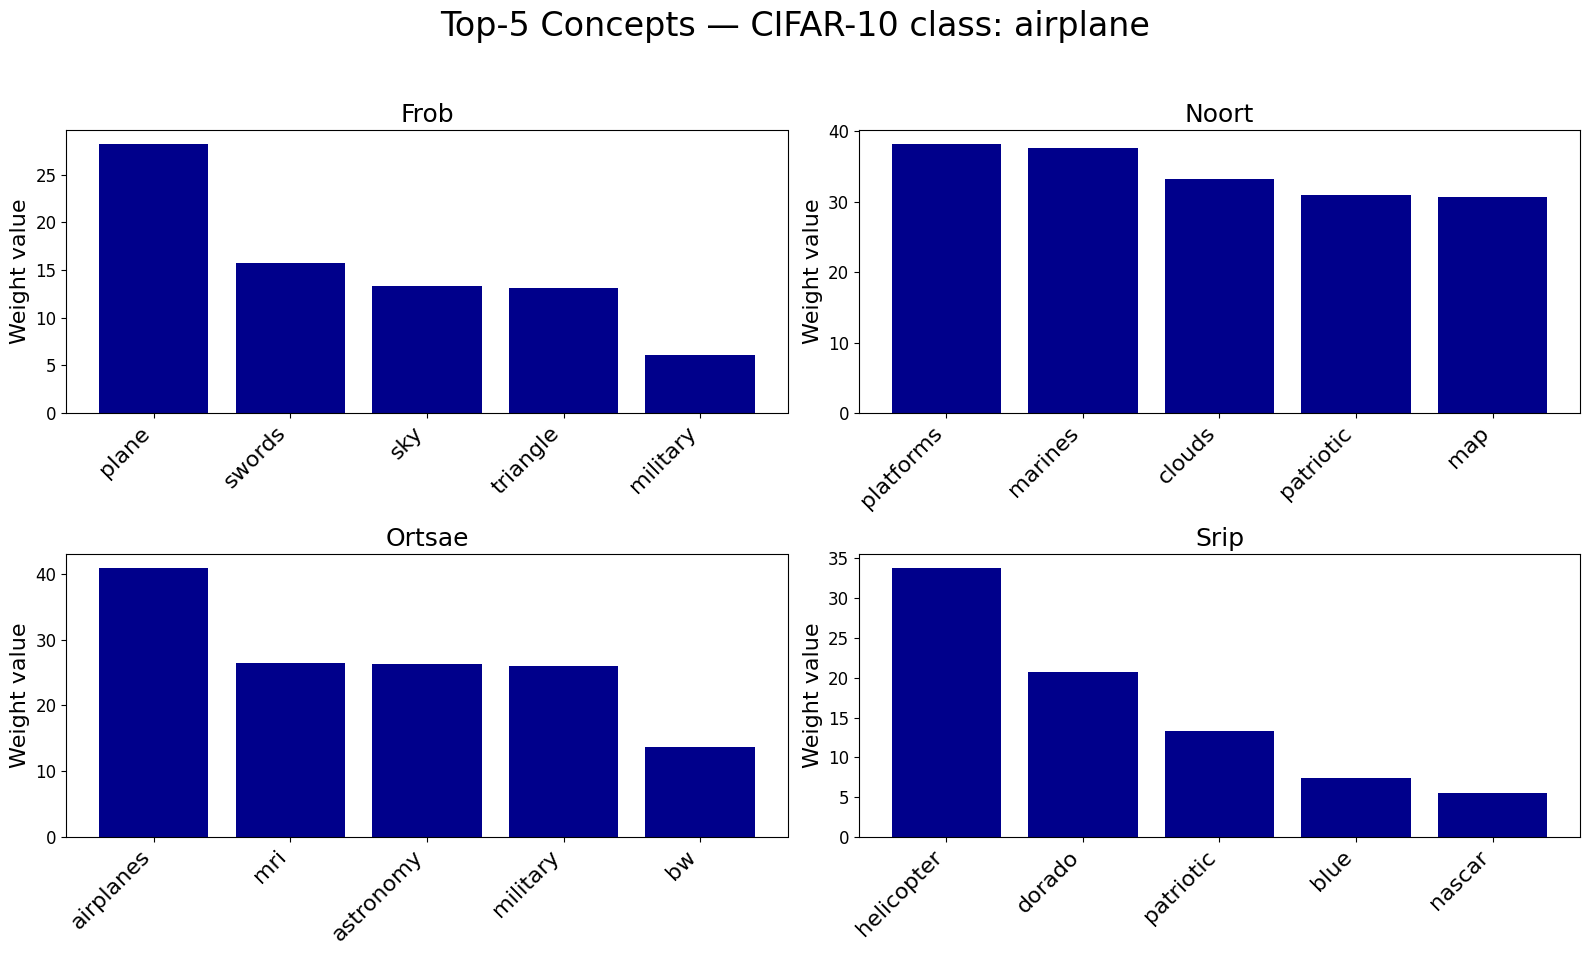

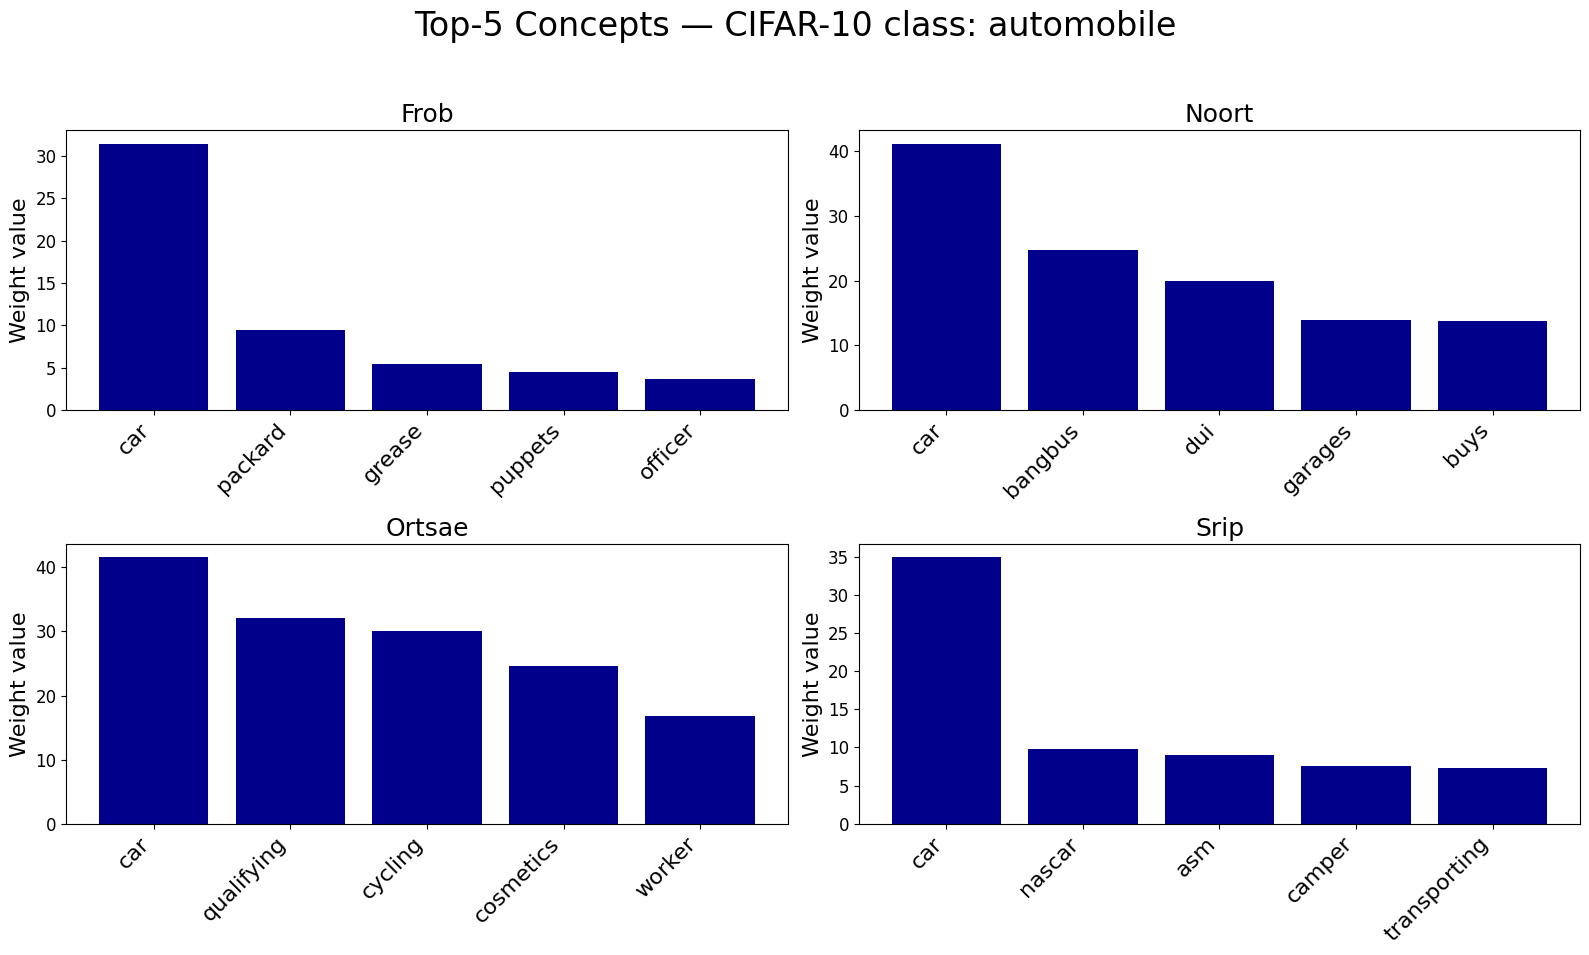

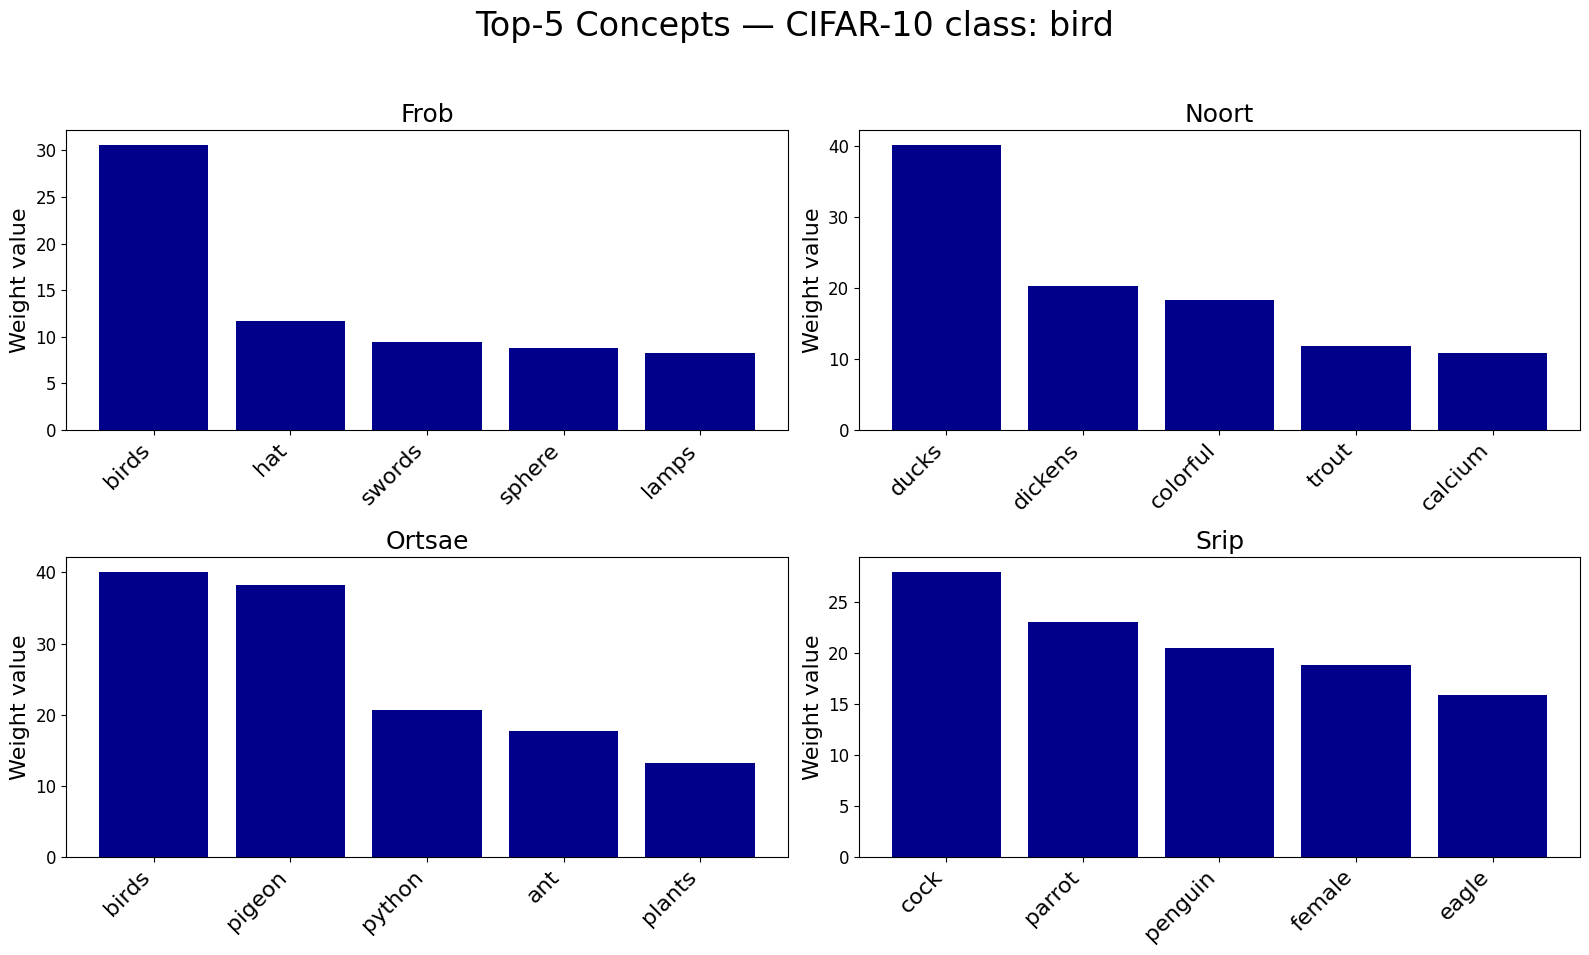

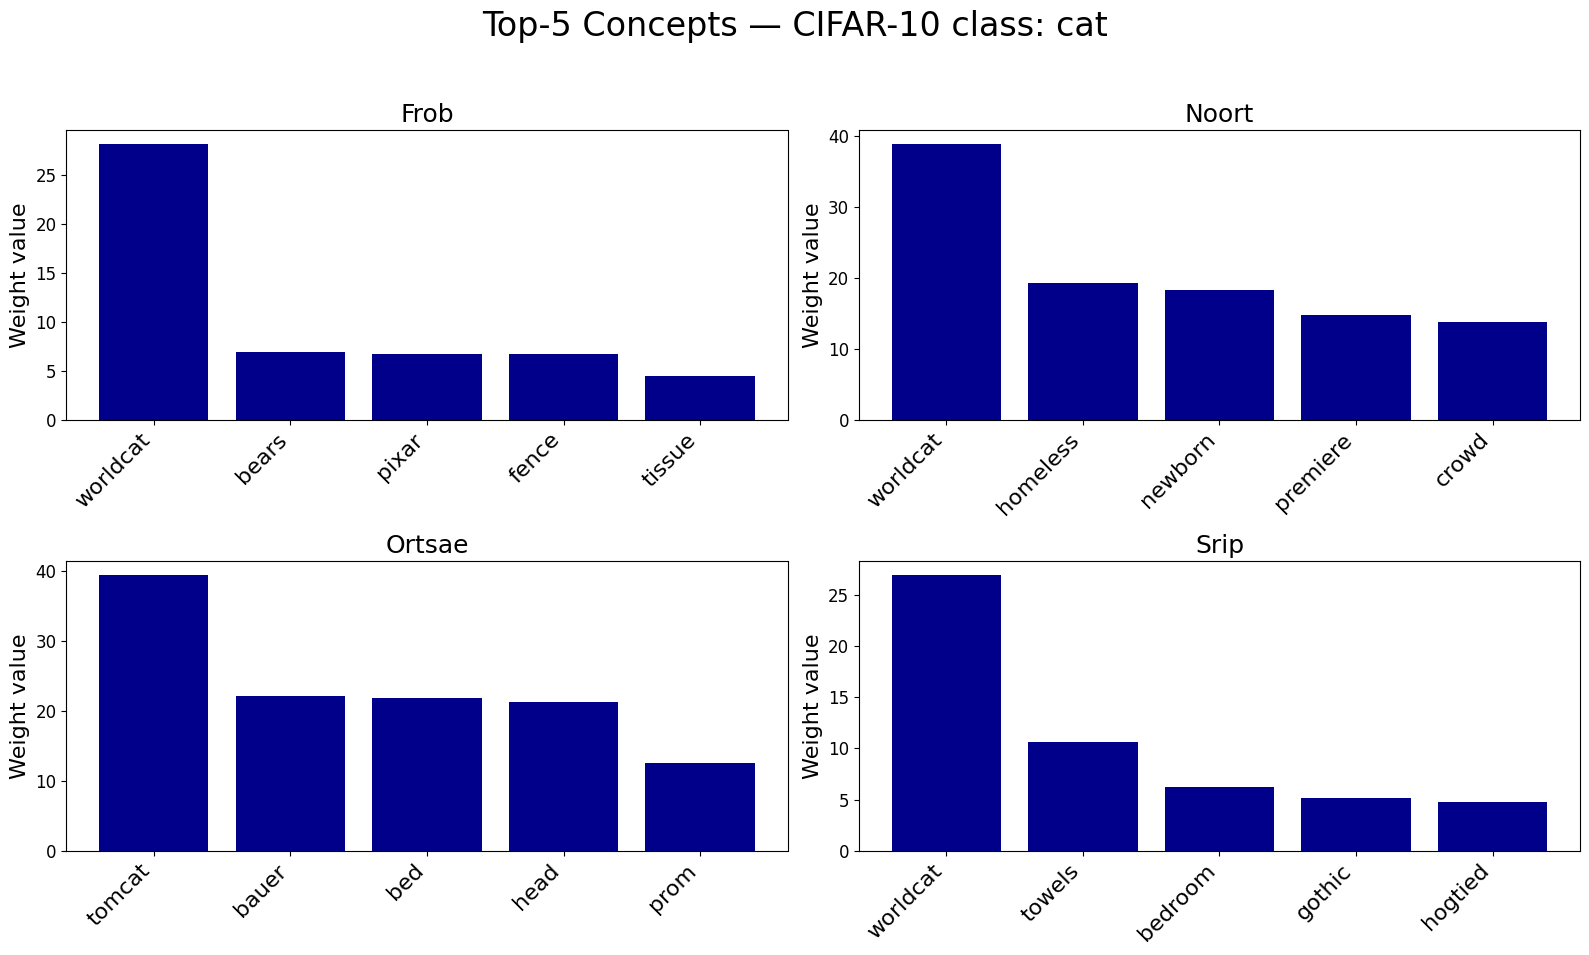

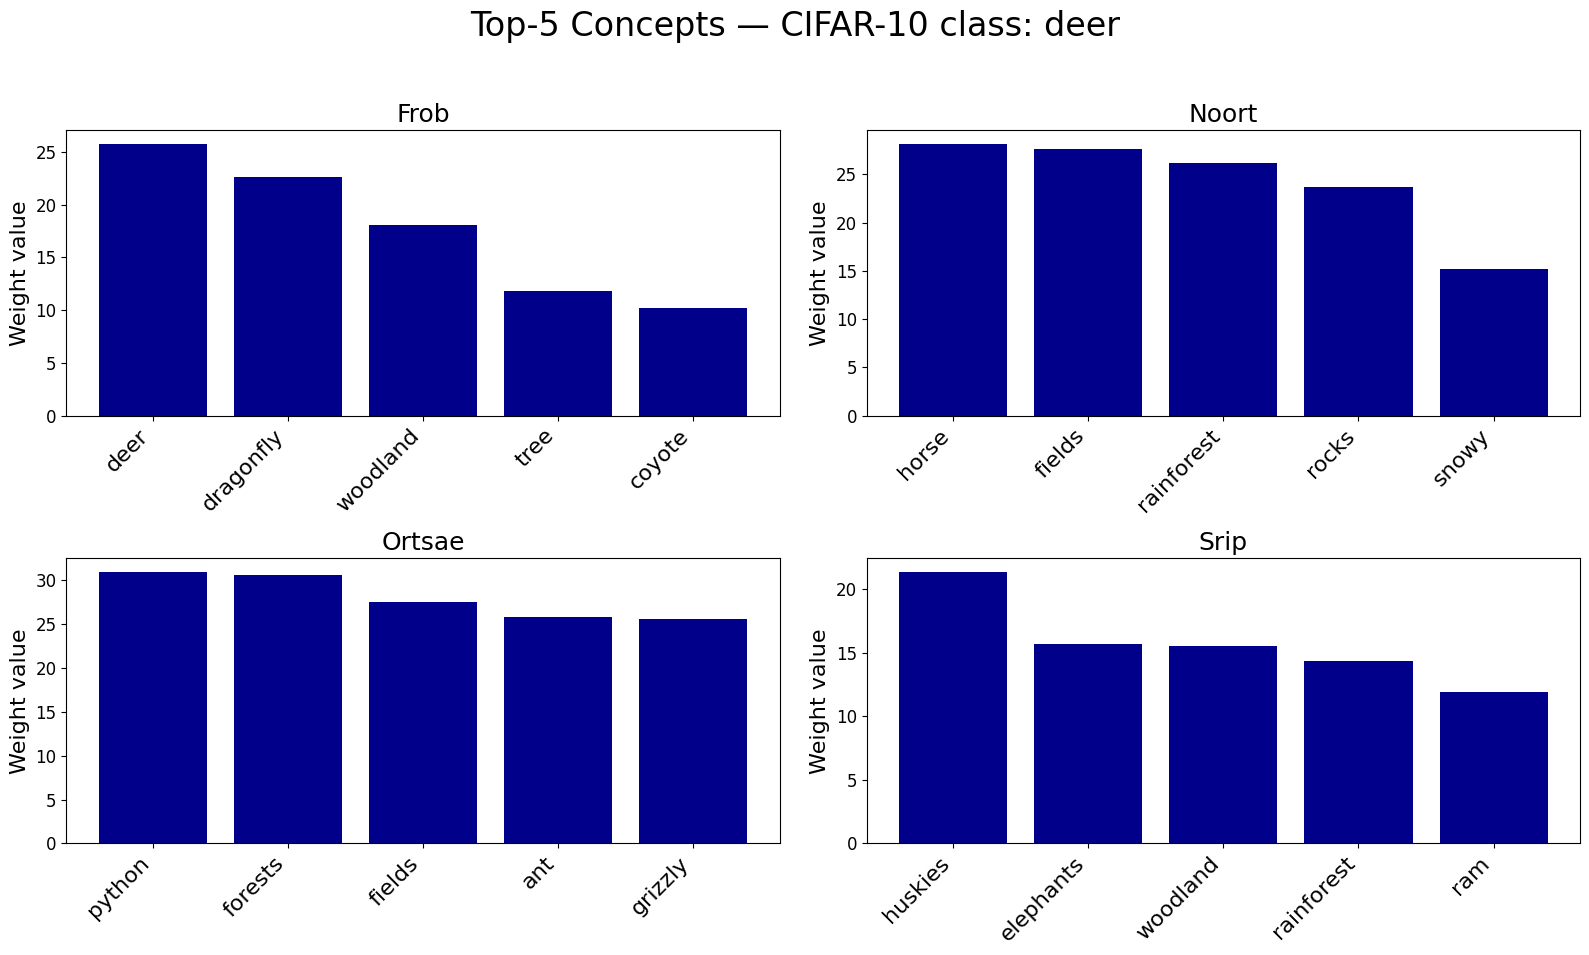

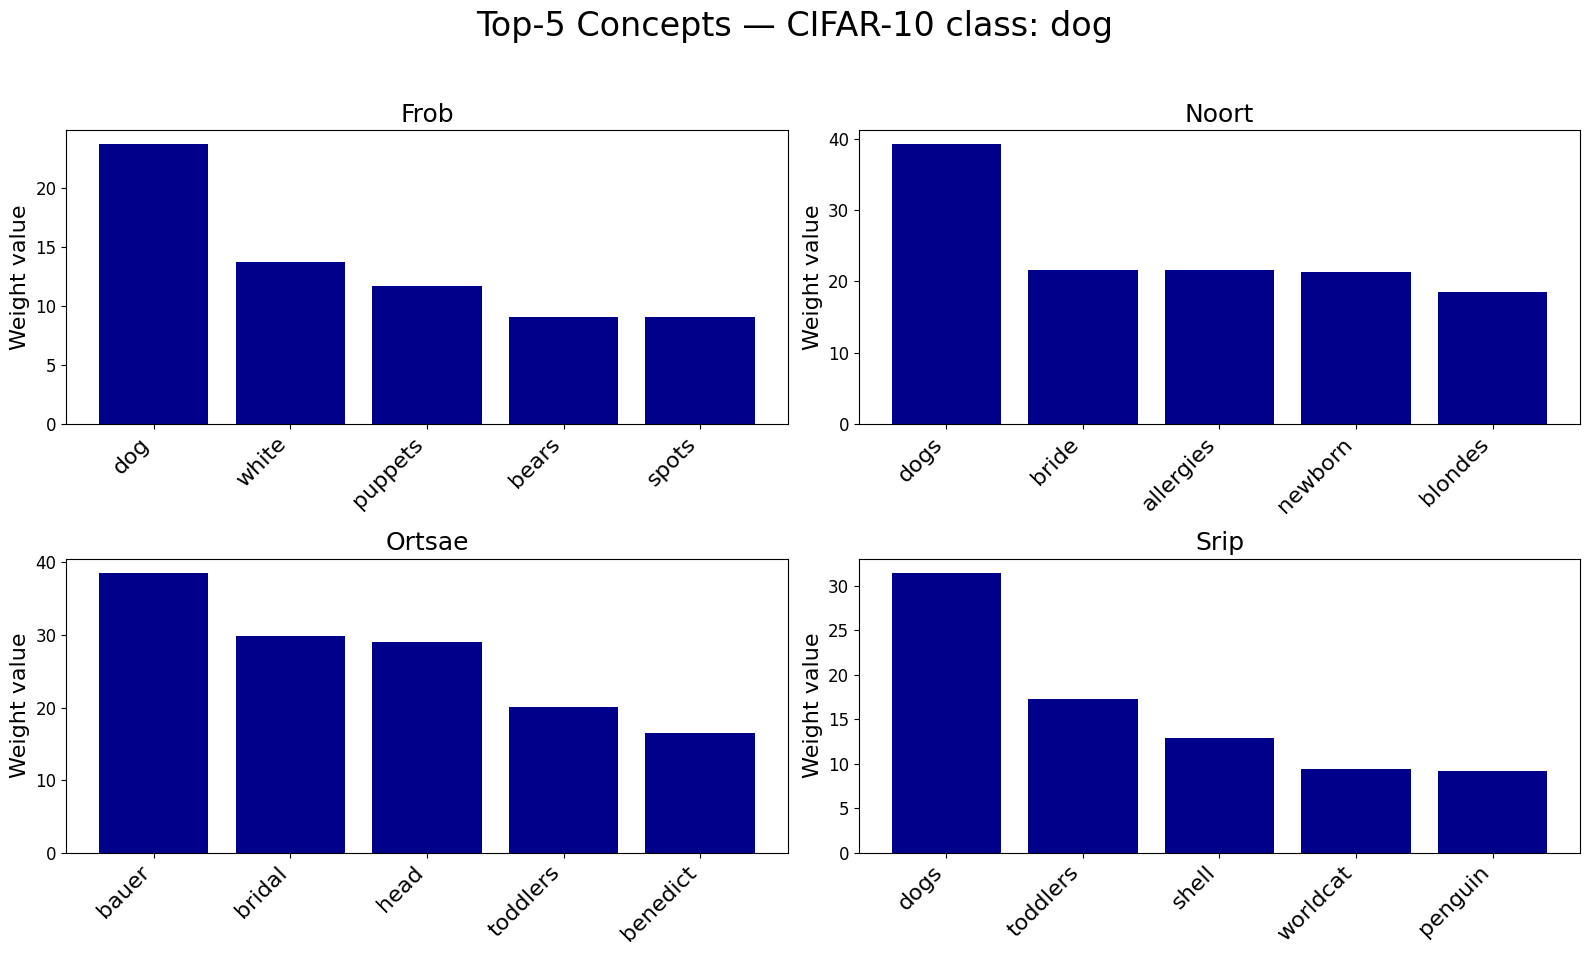

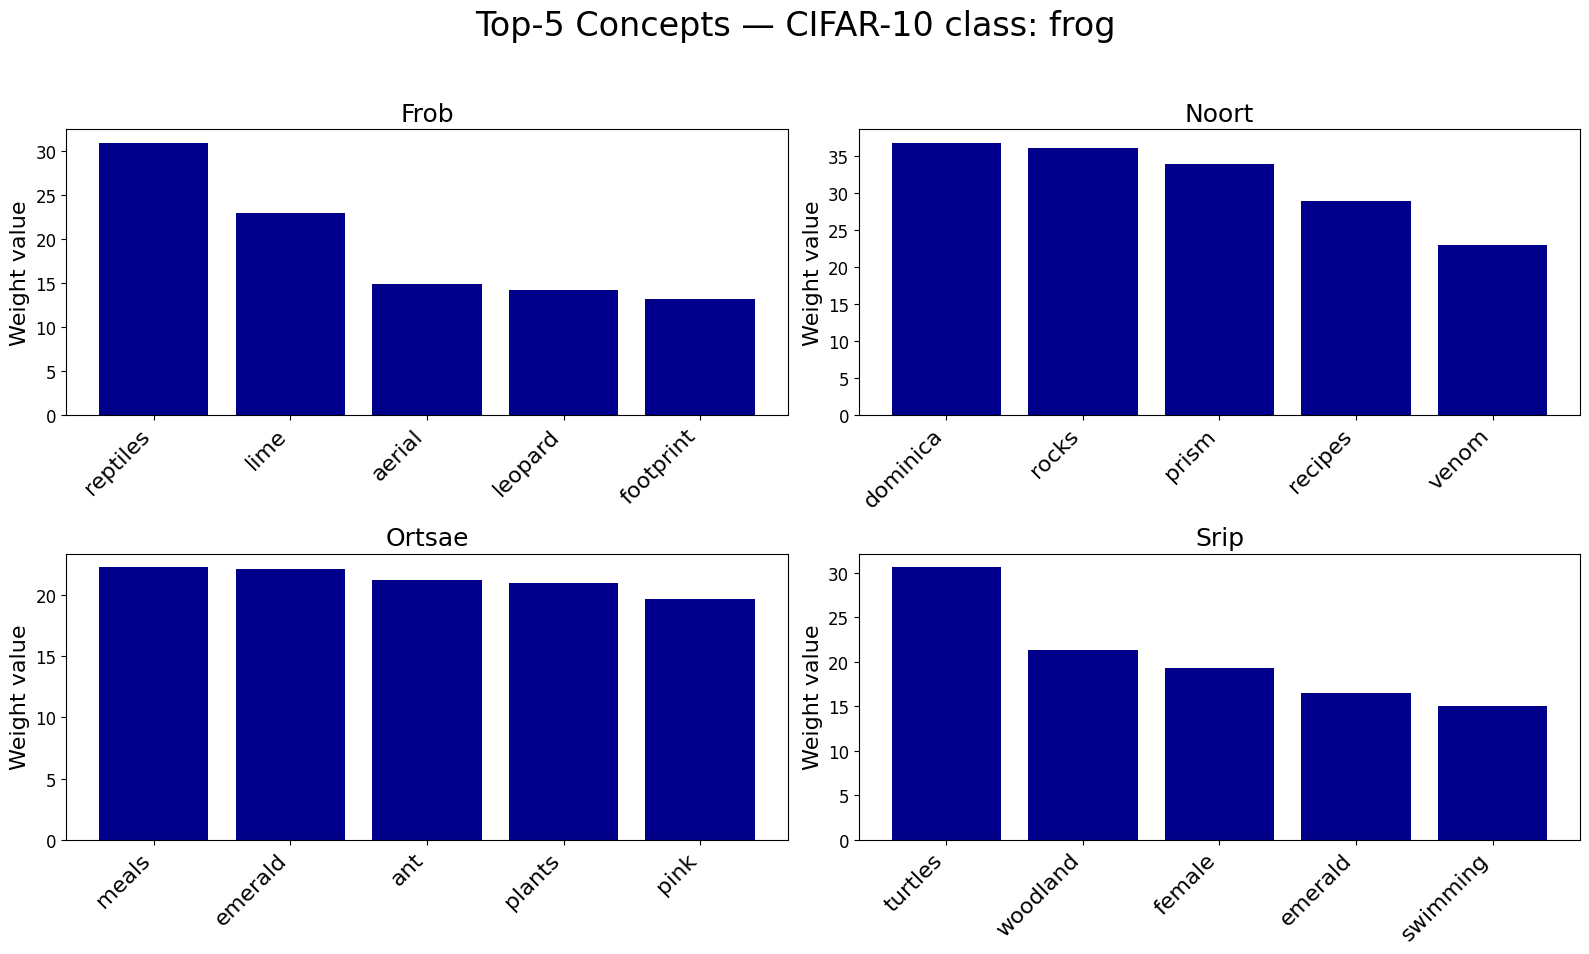

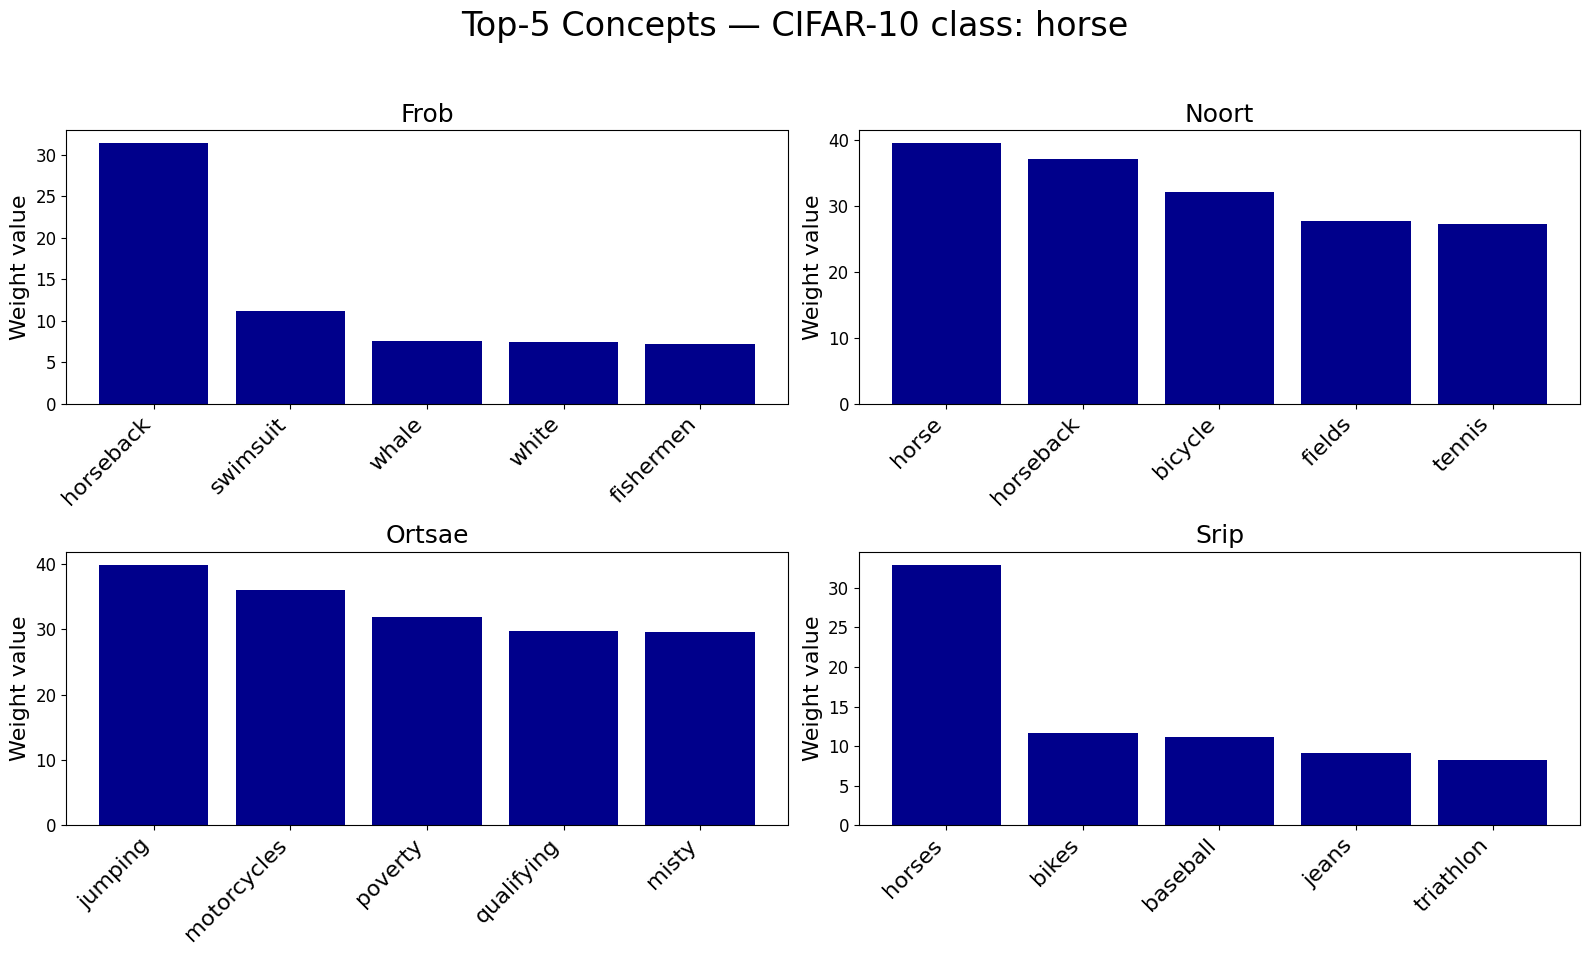

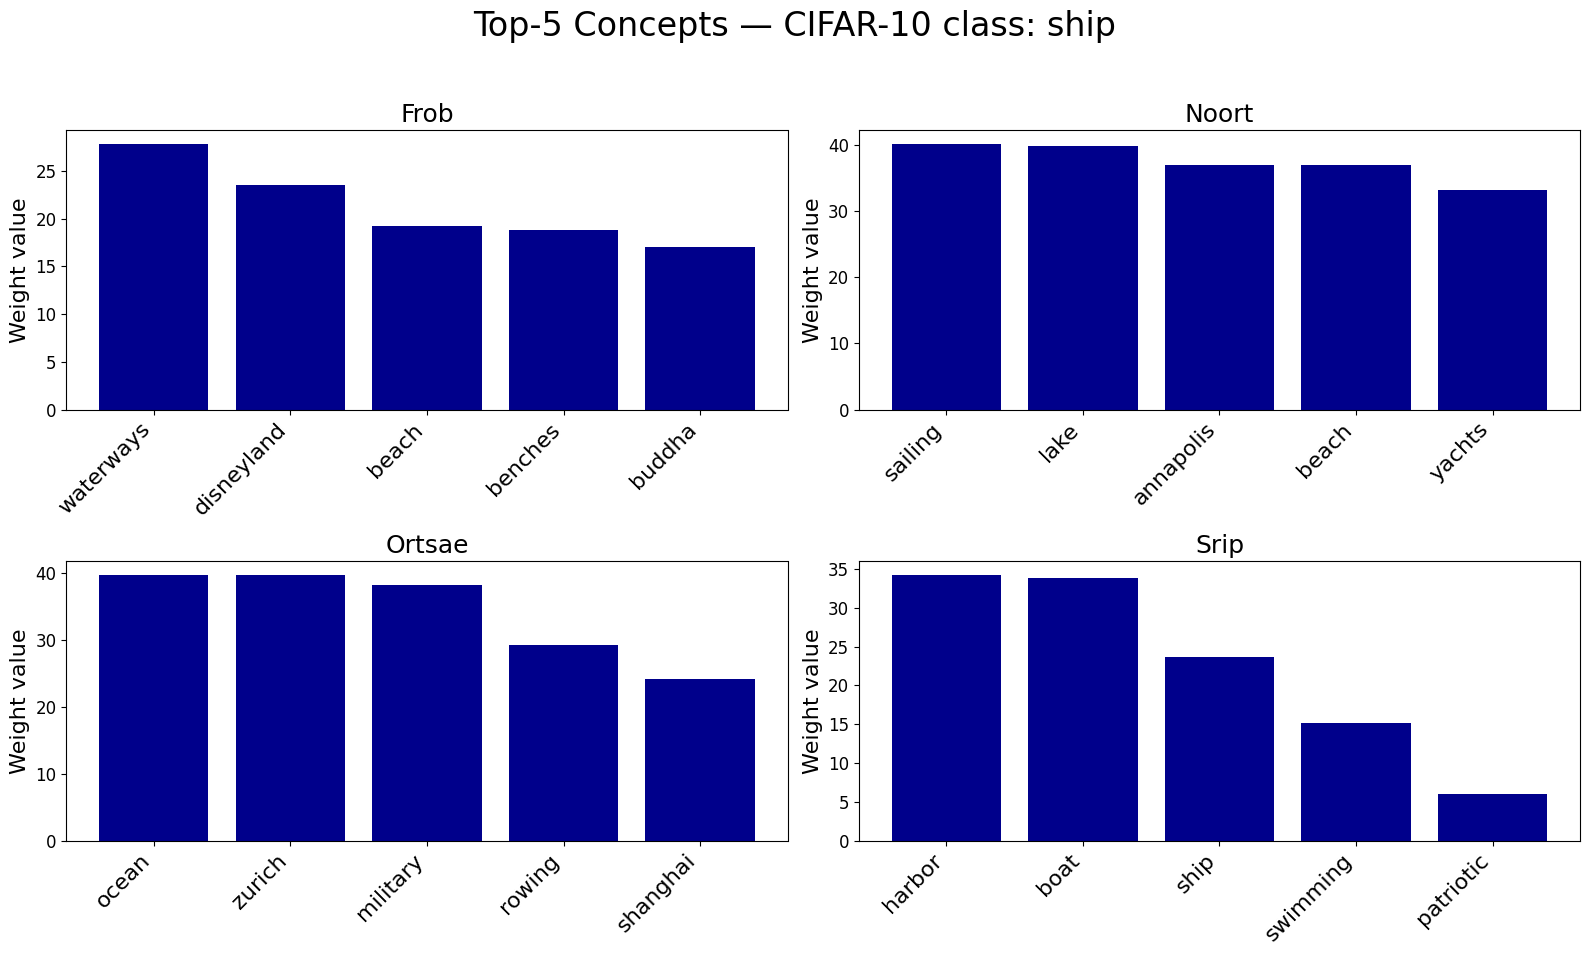

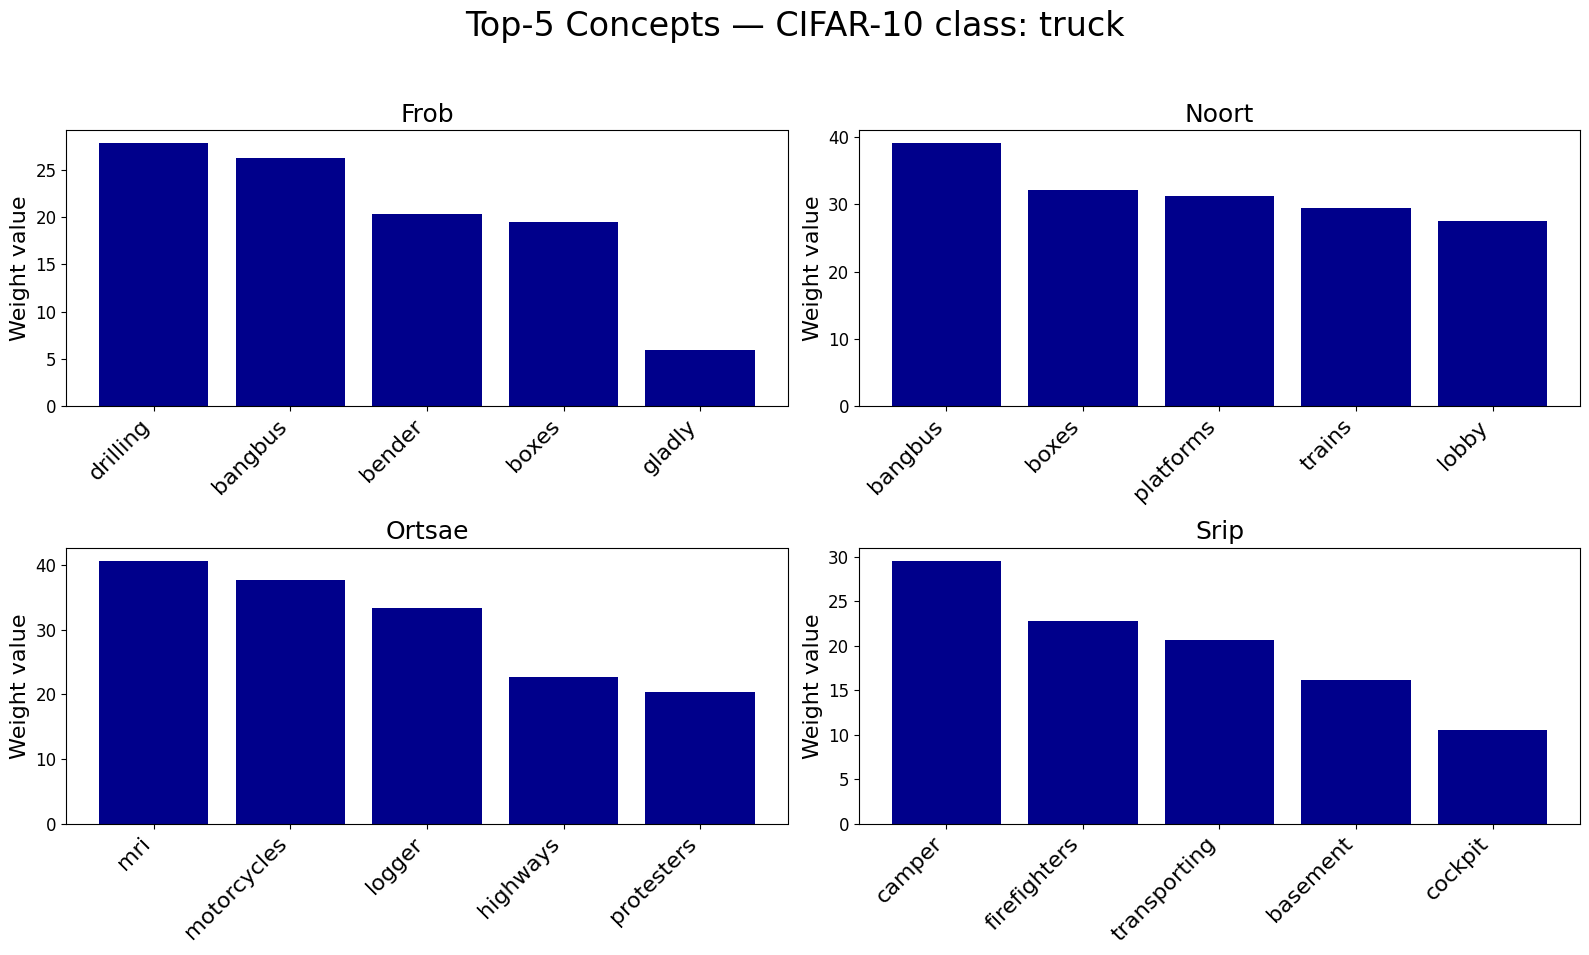

In [177]:
for class_idx, class_name in enumerate(cifar10_classes):

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax, model_name in zip(axes, model_names):
        W = weights_by_model[model_name]
        weights = W[class_idx]

        top_vals, top_idx = torch.topk(weights, k=topk)

        sorted_idx = torch.argsort(top_vals, descending=True)
        top_vals = top_vals[sorted_idx]
        top_idx = top_idx[sorted_idx]

        concepts_path = concepts_dir / f"concept_names_{model_name}.csv"
        df = pd.read_csv(concepts_path)
        concept_names = df["concept_name"].tolist()

        groups = defaultdict(list)
        for i, name in enumerate(concept_names):
            groups[name].append(i)
        unique_names = list(groups.keys())

        labels = [unique_names[i] for i in top_idx.tolist()]

        ax.bar(range(topk), top_vals.tolist(), color="darkblue")
        ax.set_xticks(range(topk))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=16)
        ax.set_ylabel("Weight value", fontsize=16)
        ax.set_title(f"{model_name.capitalize()}", fontsize=18)
        ax.tick_params(axis='y', labelsize=12)

    fig.suptitle(f"Top-{topk} Concepts — CIFAR-10 class: {class_name}", fontsize=24)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    plt.show()


## Find top activating images


In [ ]:
def load_unique_concept_names(concept_csv_path):
    df = pd.read_csv(concept_csv_path)

    concept_names = df["concept_name"].tolist()
    unique_concept_names = pd.unique(concept_names).tolist()

    return unique_concept_names

def get_concept_index(word, unique_concept_names):
    if word not in unique_concept_names:
        raise ValueError(
            f"Concept '{word}' not found. "
            f"Examples: {unique_concept_names[:10]}"
        )
    return unique_concept_names.index(word)


def load_cifar10_test_images(test_batch_path):
    with open(test_batch_path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")

    images = batch[b"data"]
    images = images.reshape(-1, 3, 32, 32)
    images = images.transpose(0, 2, 3, 1)
    return images


def visualize_top_activations(
    word,
    model_name,
    project_root="./",
    top_k=20,
):
    concepts_path = os.path.join(
        project_root,
        "data/concept_names",
        f"concept_names_{model_name}.csv",
    )

    latent_path = os.path.join(
        project_root,
        "data/sae_embeddings/cifar10/collapsed",
        model_name,
        "test_latent.pt",
    )

    cifar_test_path = os.path.join(
        project_root,
        "data/datasets/cifar-10-batches-py/test_batch",
    )

    unique_concepts = load_unique_concept_names(concepts_path)
    concept_idx = get_concept_index(word, unique_concepts)

    latents_dict = torch.load(latent_path, map_location="cpu")
    latents = latents_dict["latents"]

    activations = latents[:, concept_idx]

    topk_vals, topk_idx = torch.topk(activations, top_k)
    images = load_cifar10_test_images(cifar_test_path)
    selected_images = images[topk_idx.numpy()]

    fig, axes = plt.subplots(4, 5, figsize=(12, 10))
    axes = axes.flatten()

    for ax, img, val in zip(axes, selected_images, topk_vals):
        ax.imshow(img)
        ax.set_title(f"{val.item():.3f}", fontsize=9)
        ax.axis("off")

    plt.suptitle(
        f"{model_name.upper()}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

FROB


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


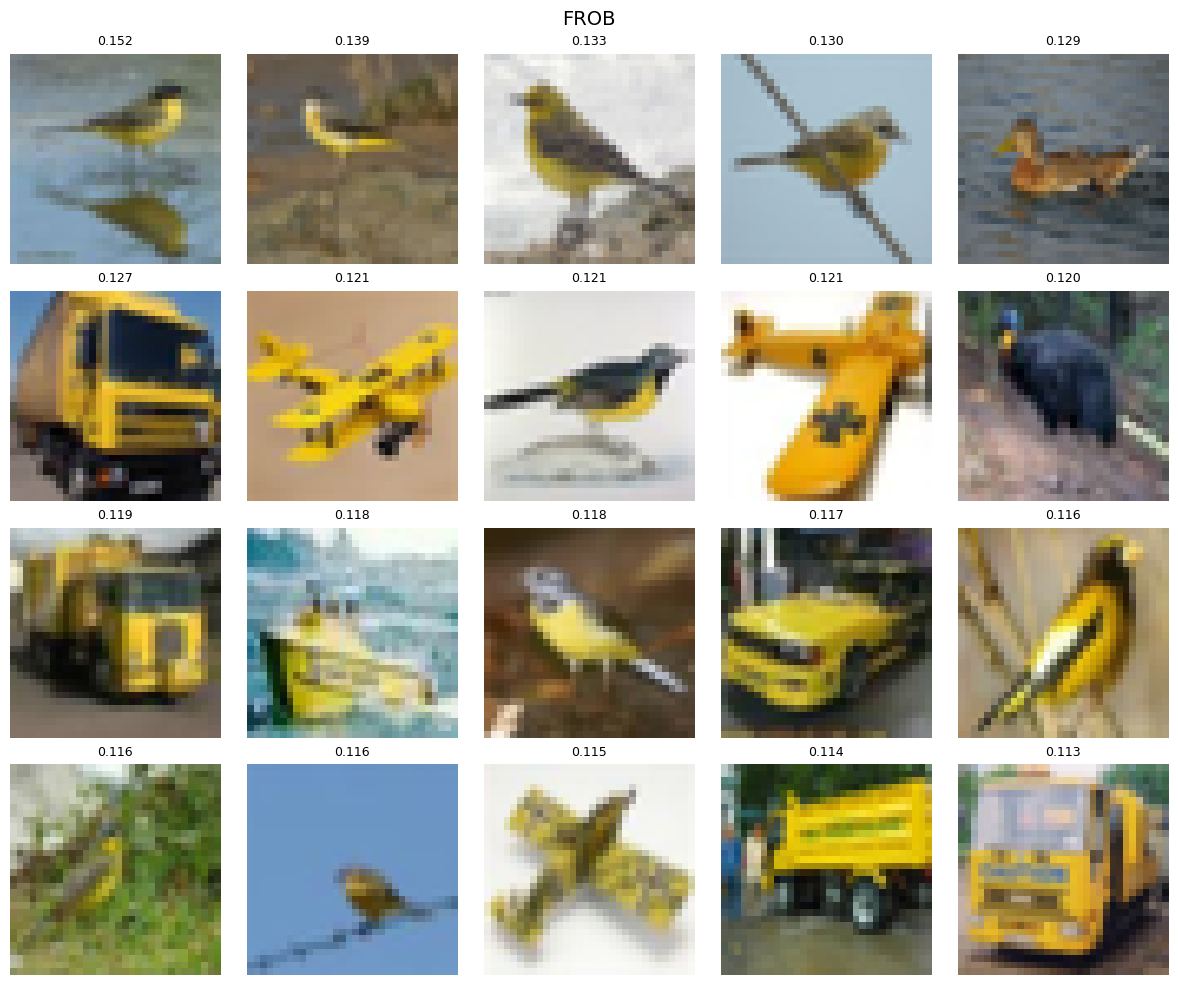

NOORT


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


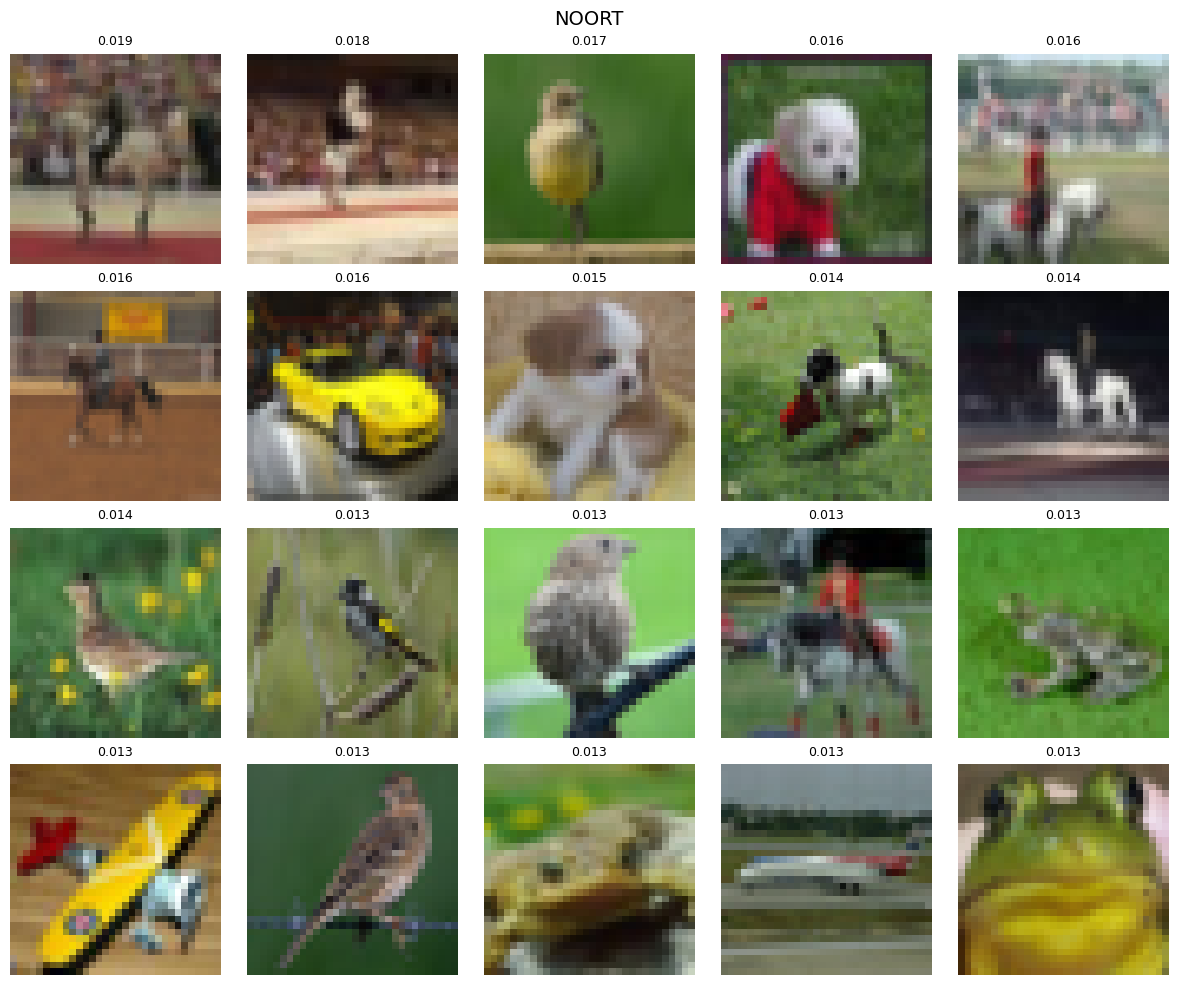

ORTSAE


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


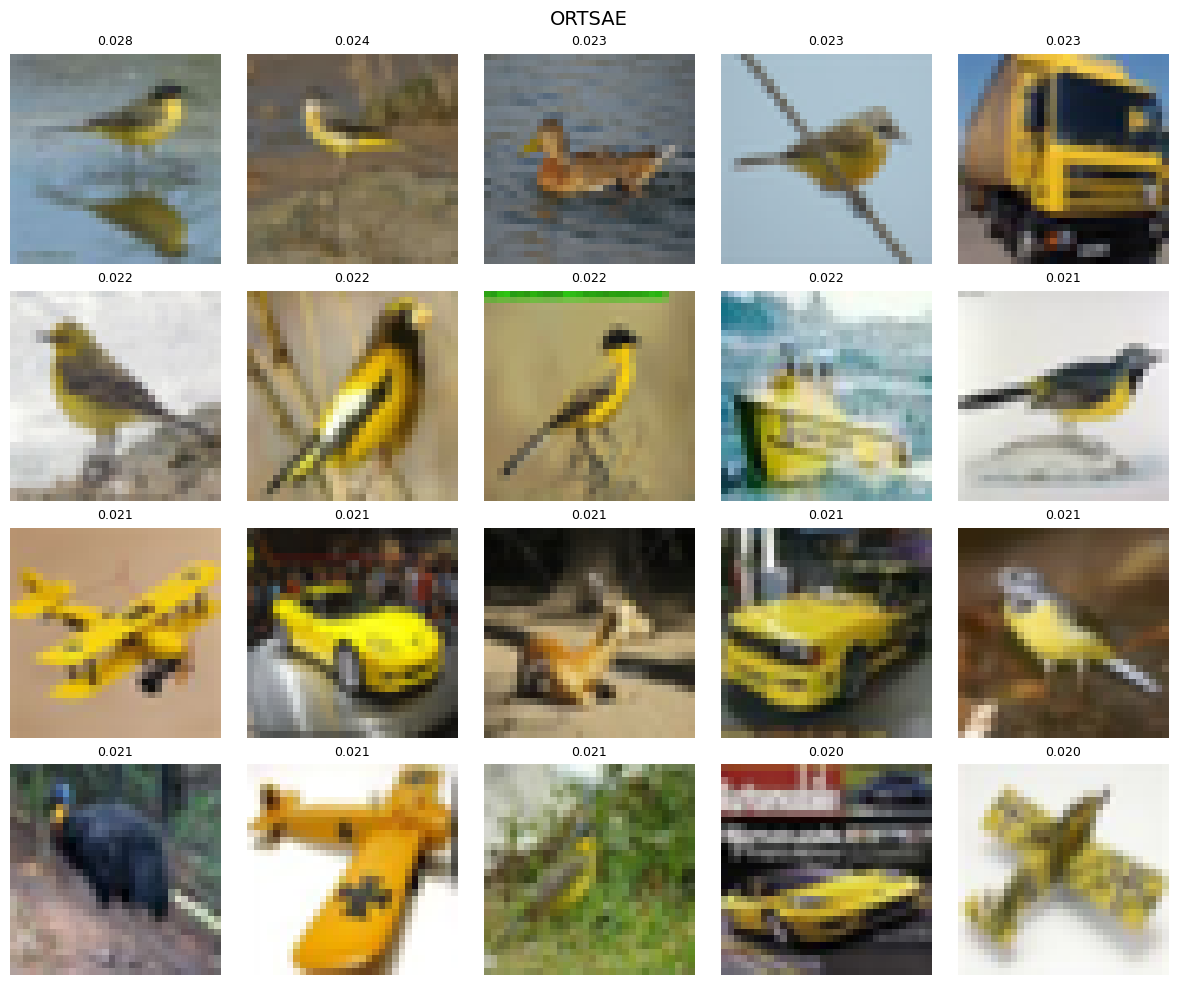

SRIP


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


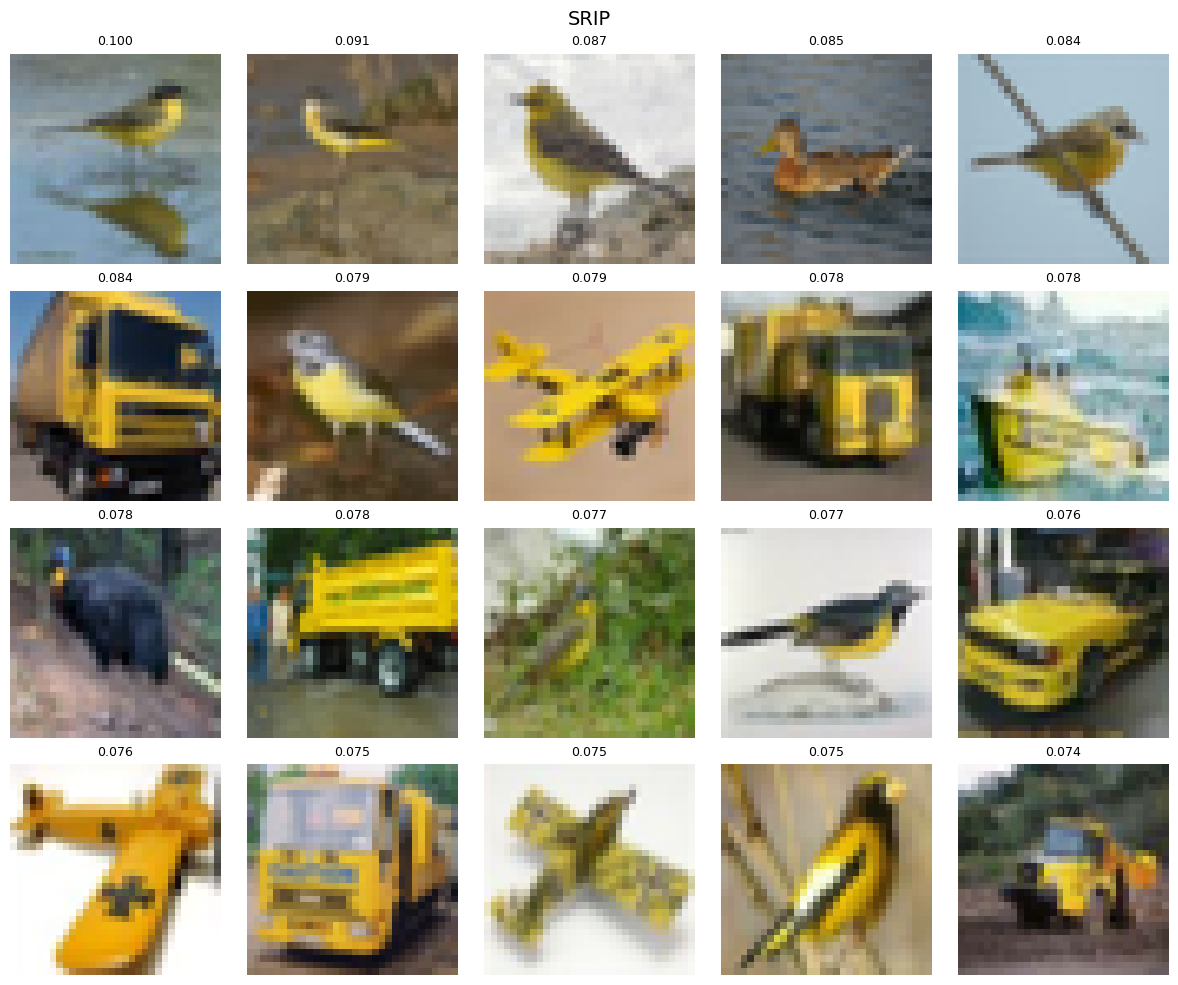

In [ ]:
for model in ["frob", "noort", "ortsae", "srip"]:
    try:
        print(model.upper())
        visualize_top_activations("yellow", model)
    except:
        continue

FROB


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


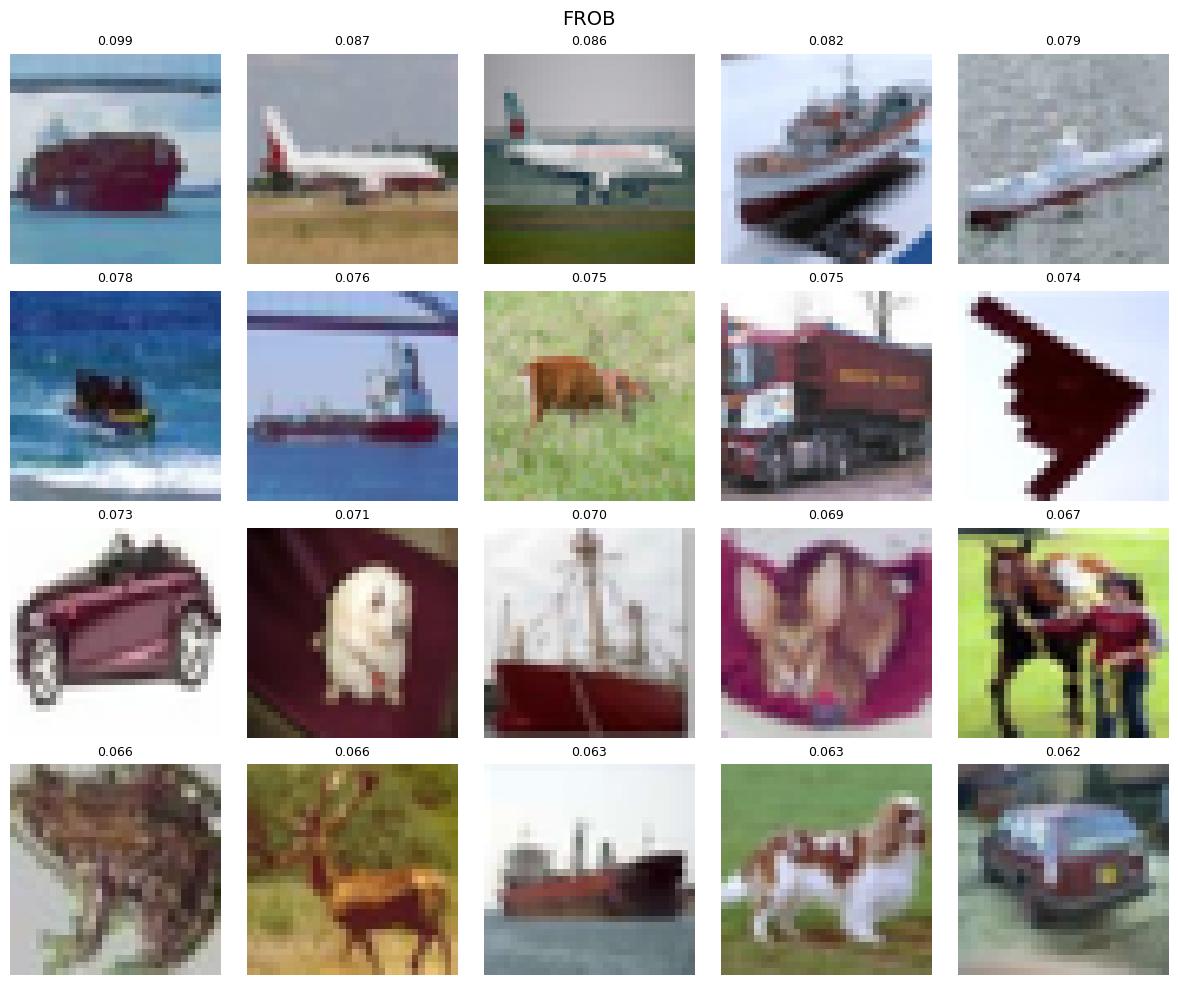

NOORT


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


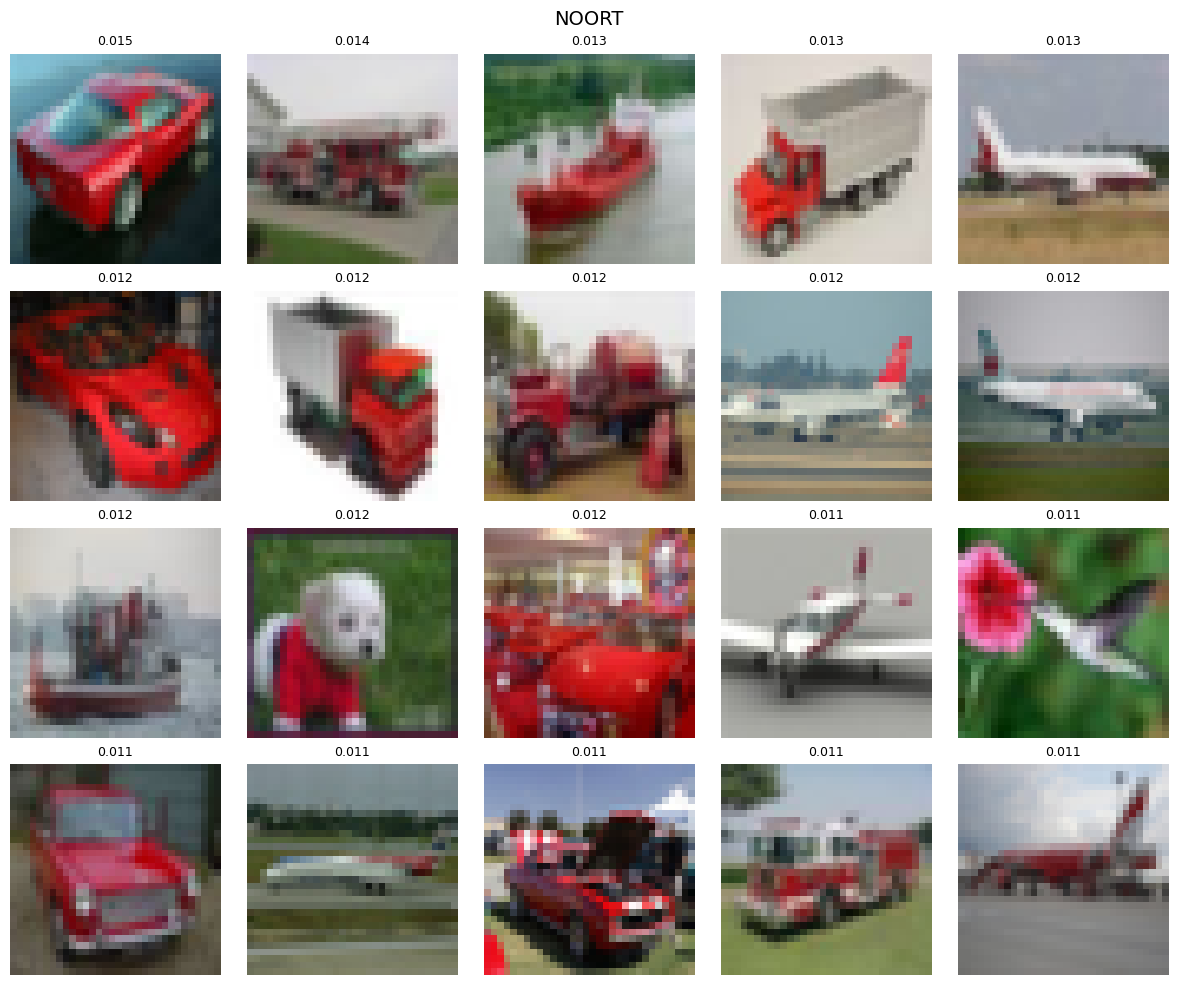

ORTSAE


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


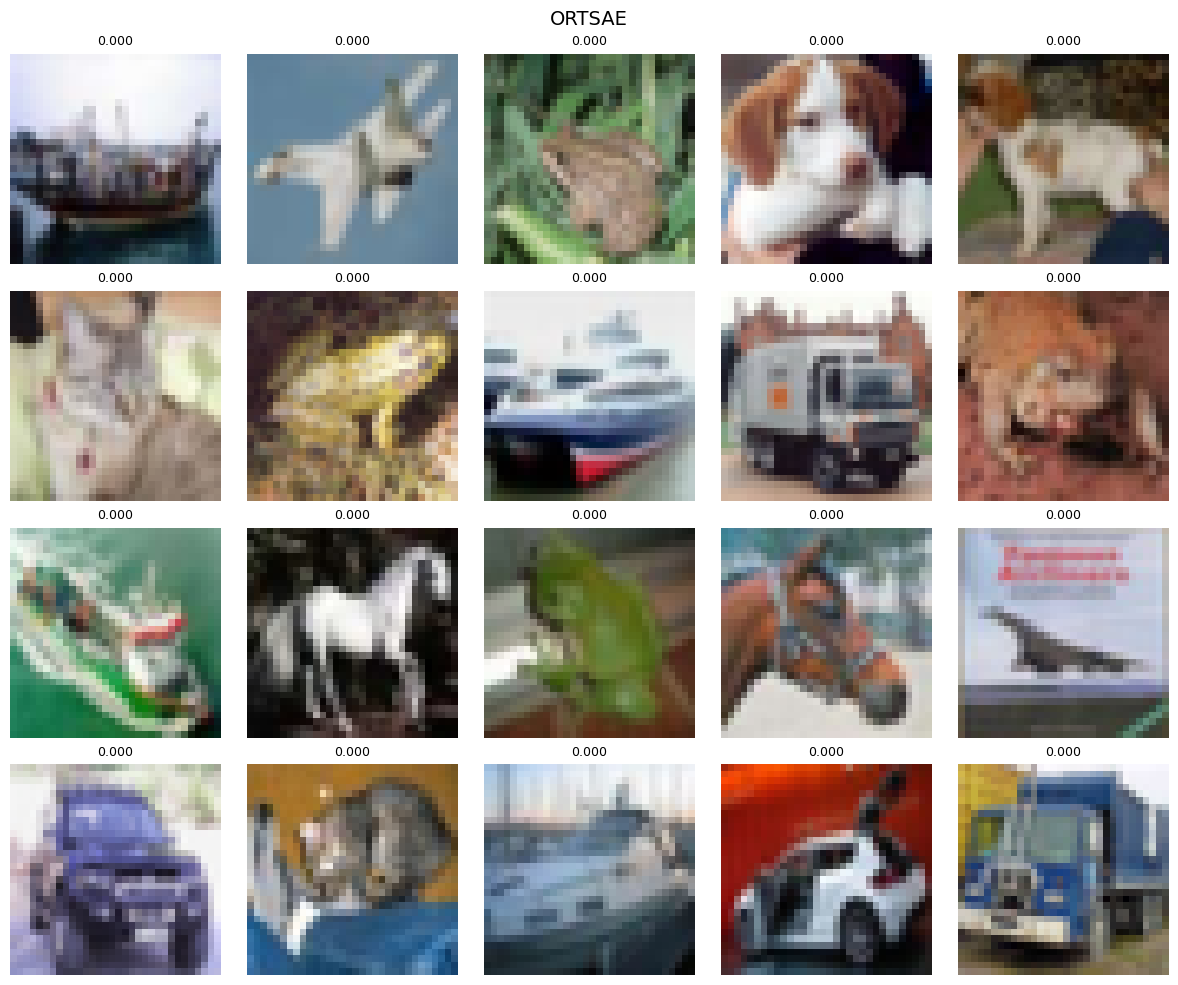

SRIP


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


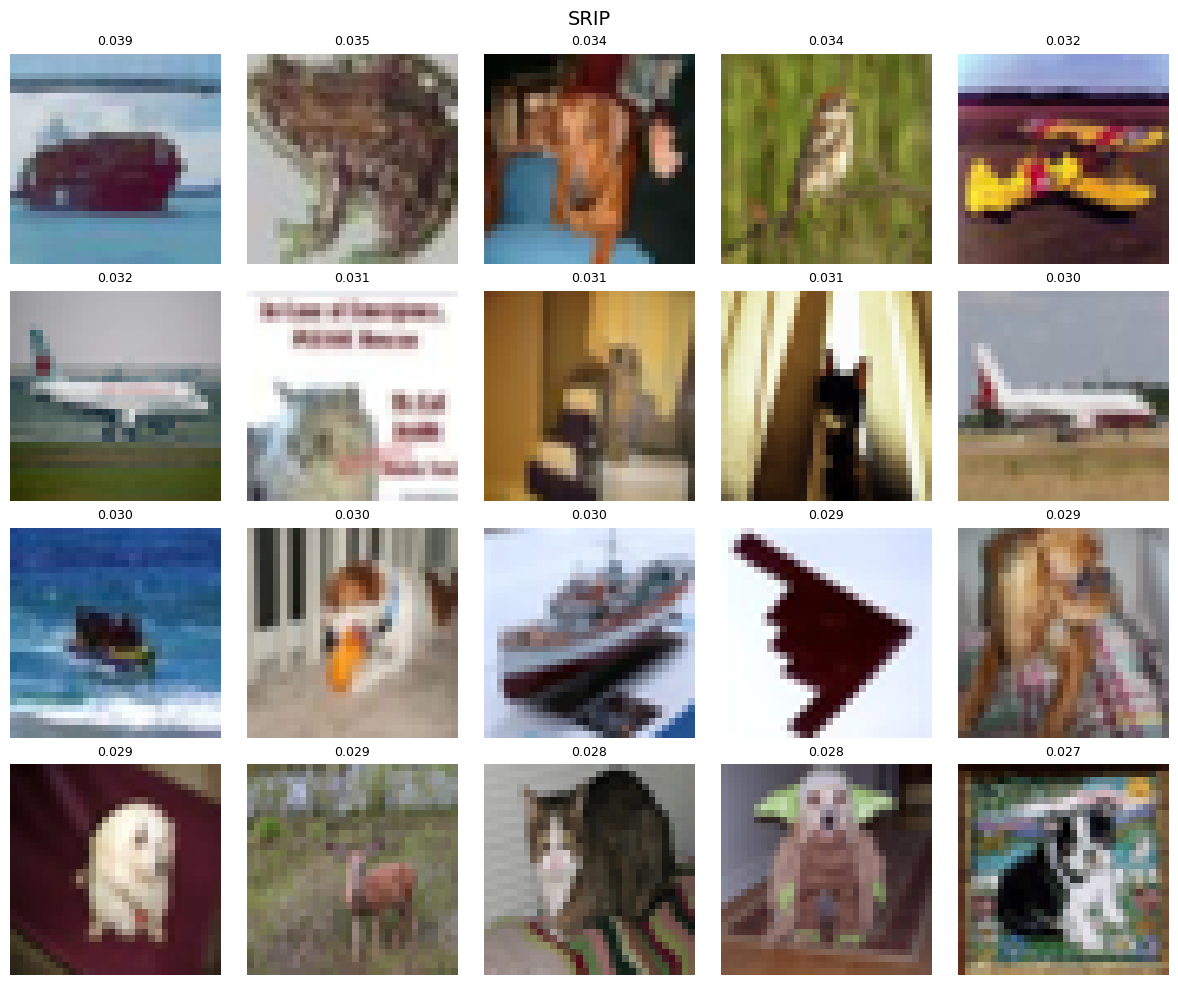

In [181]:
for model in ["frob", "noort", "ortsae", "srip"]:
    try:
        print(model.upper())
        visualize_top_activations("burgundy", model)
    except:
        continue

FROB


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


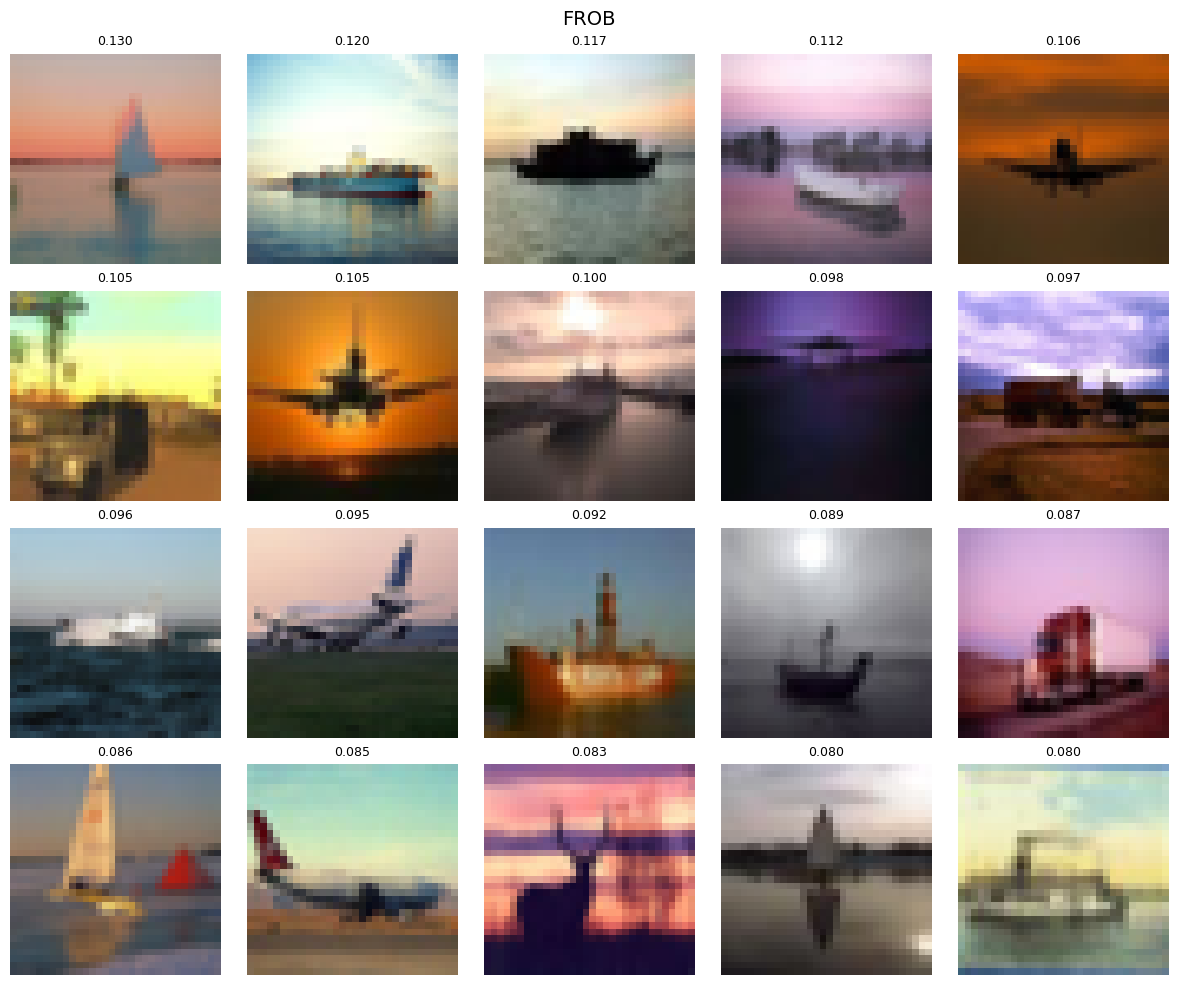

NOORT


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


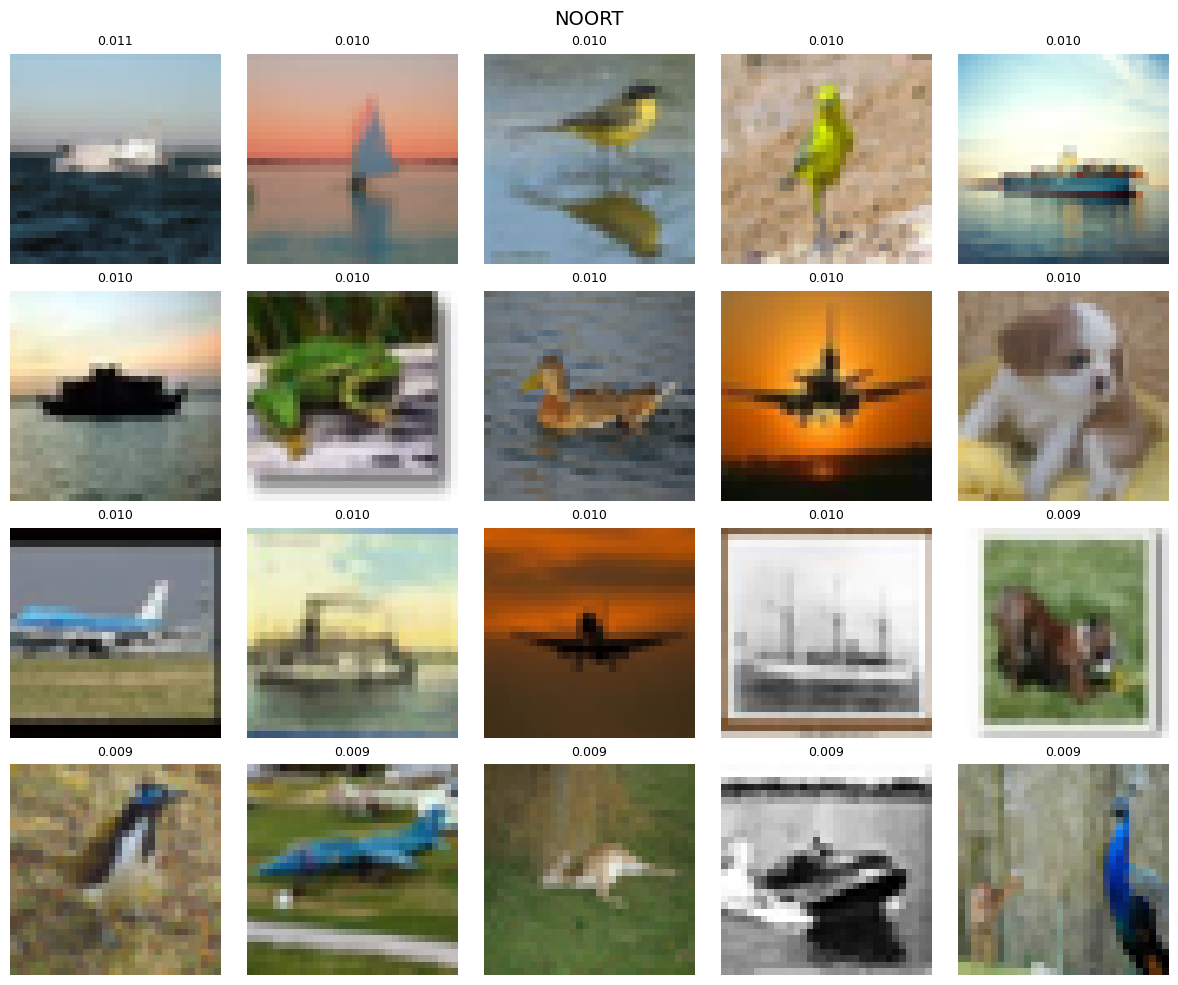

ORTSAE


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


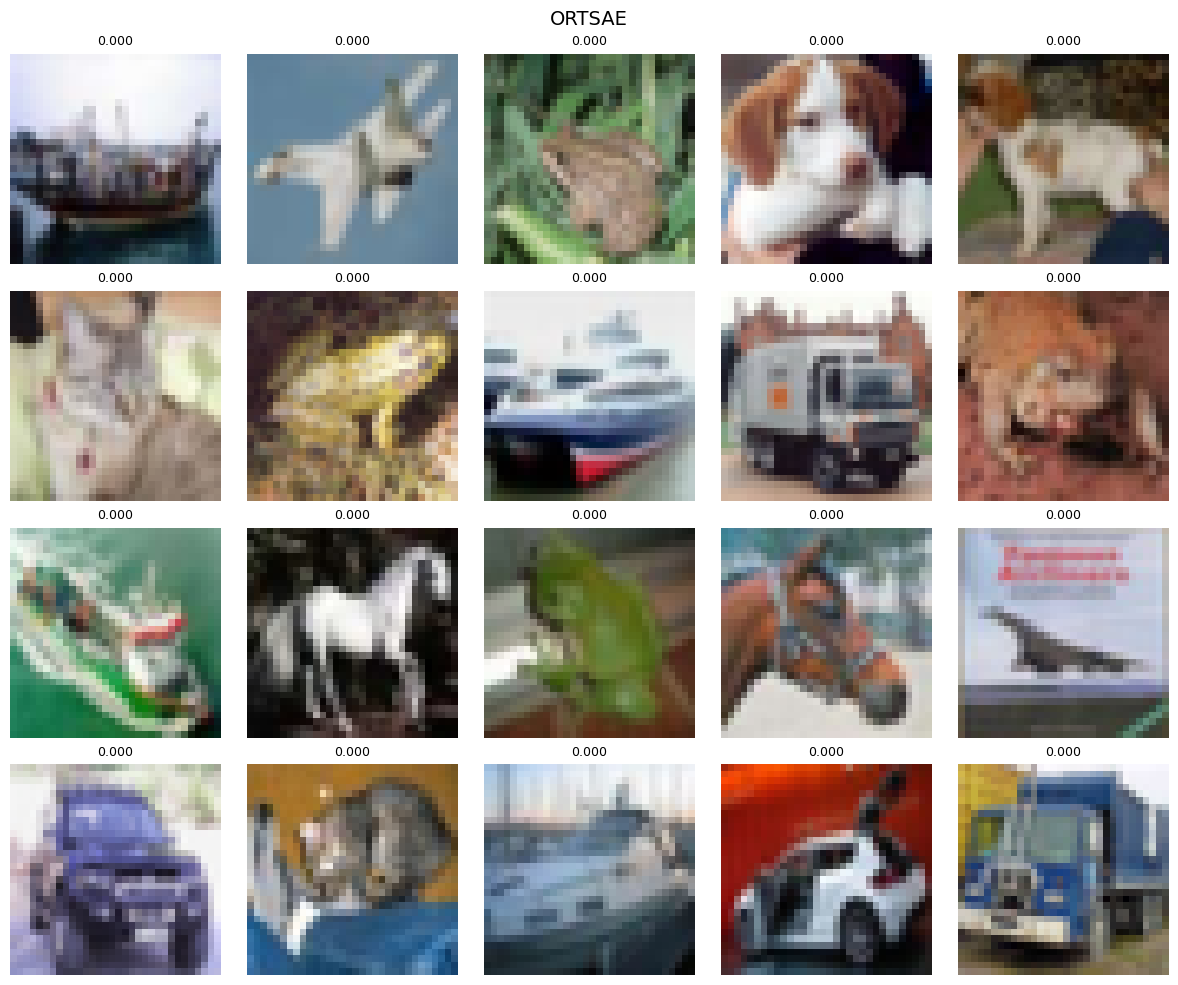

SRIP


/tmp/ipykernel_486823/2046180653.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_concept_names = pd.unique(concept_names).tolist()


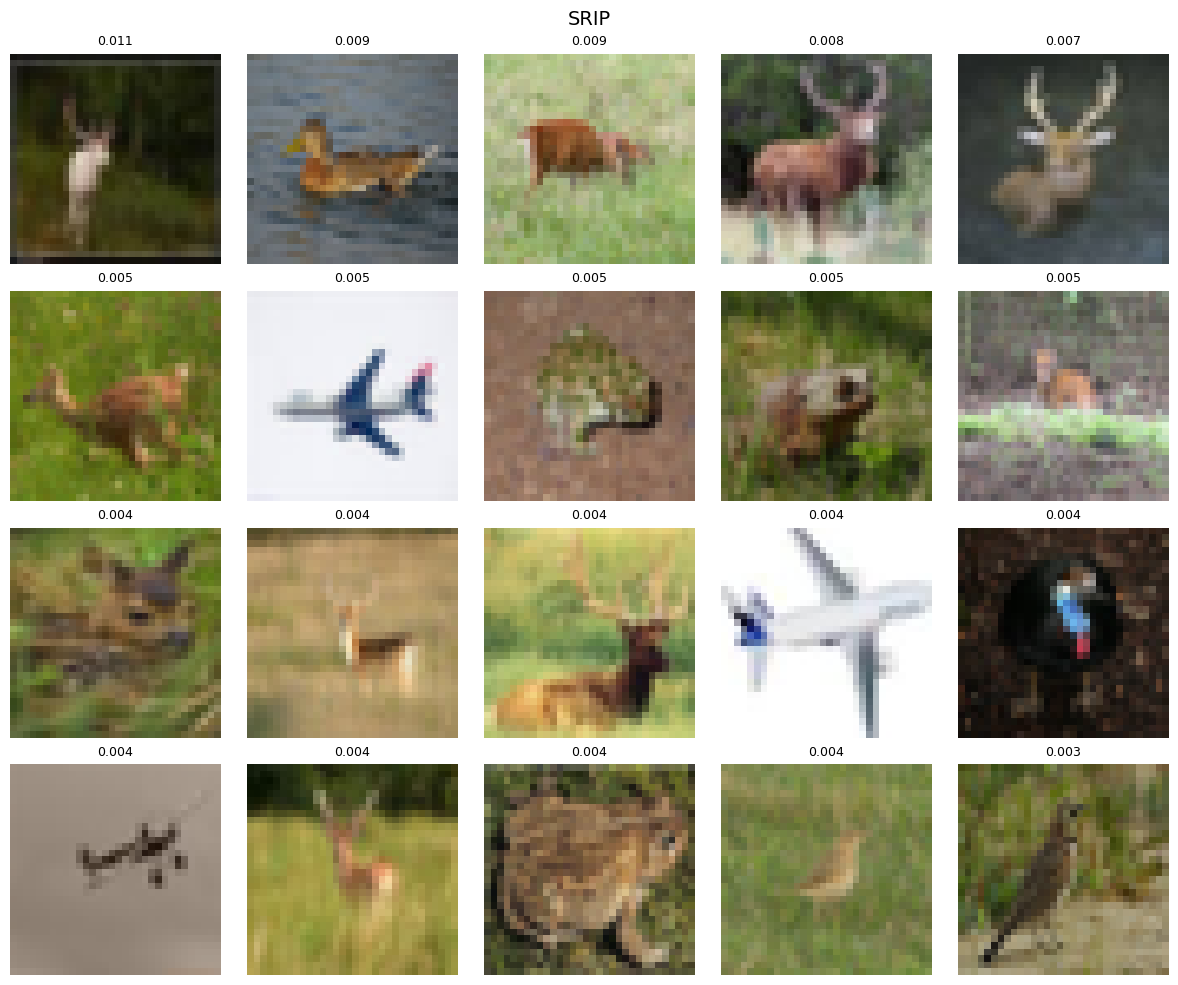

In [182]:
for model in ["frob", "noort", "ortsae", "srip"]:
    try:
        print(model.upper())
        visualize_top_activations("sunset", model)
    except:
        continue